<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fanirudhk/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [ ]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_899/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_899/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


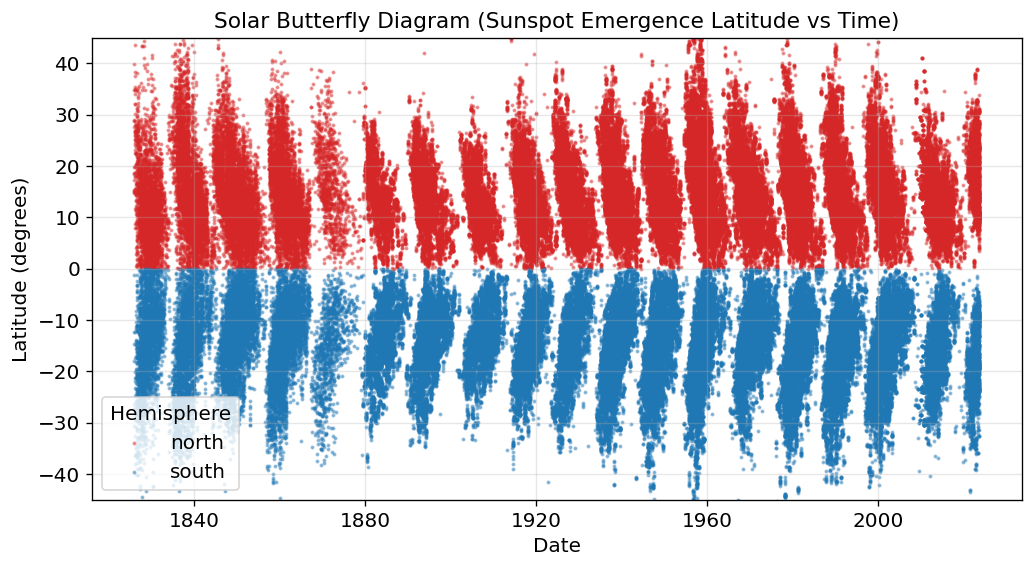

In [ ]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


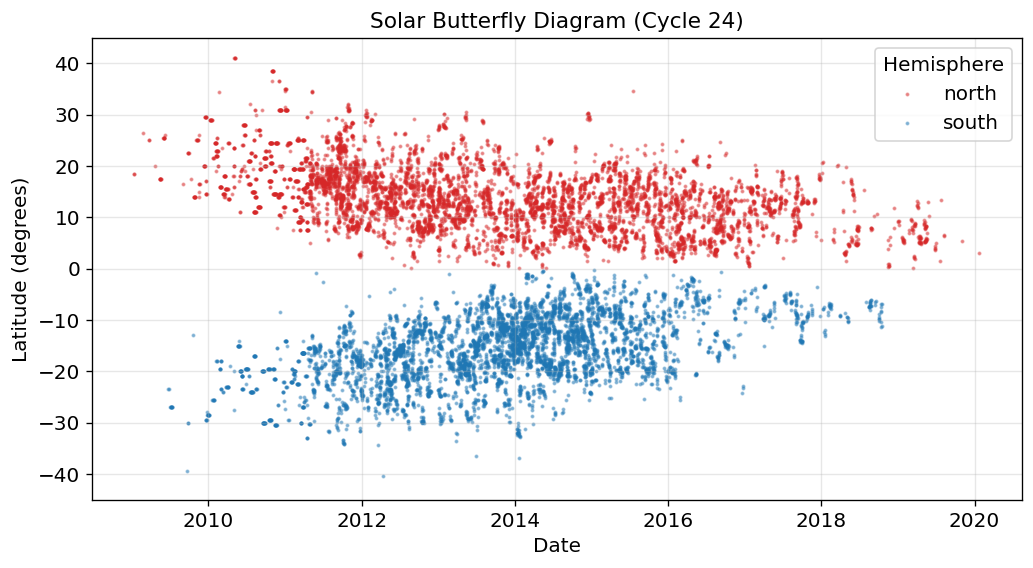

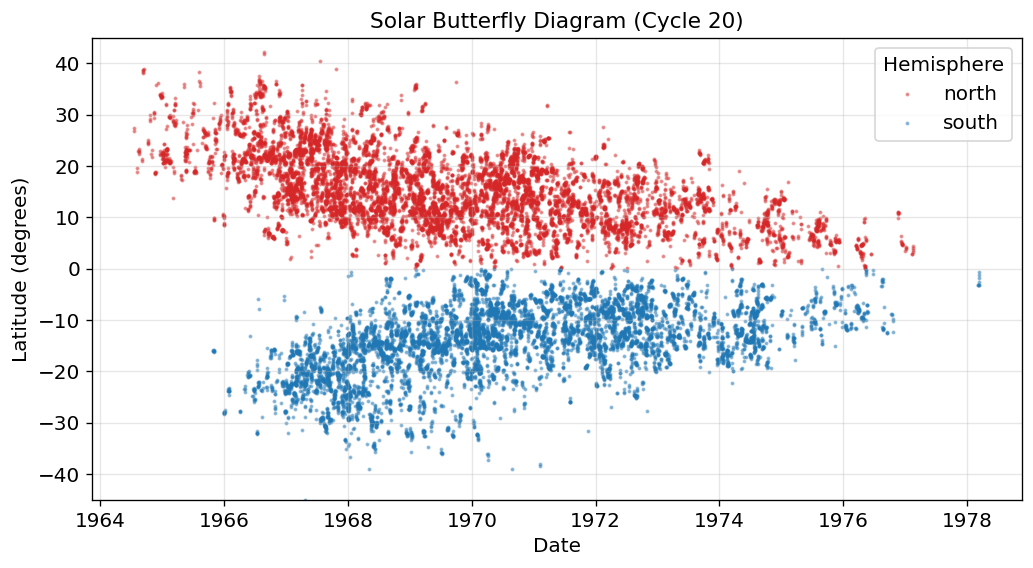

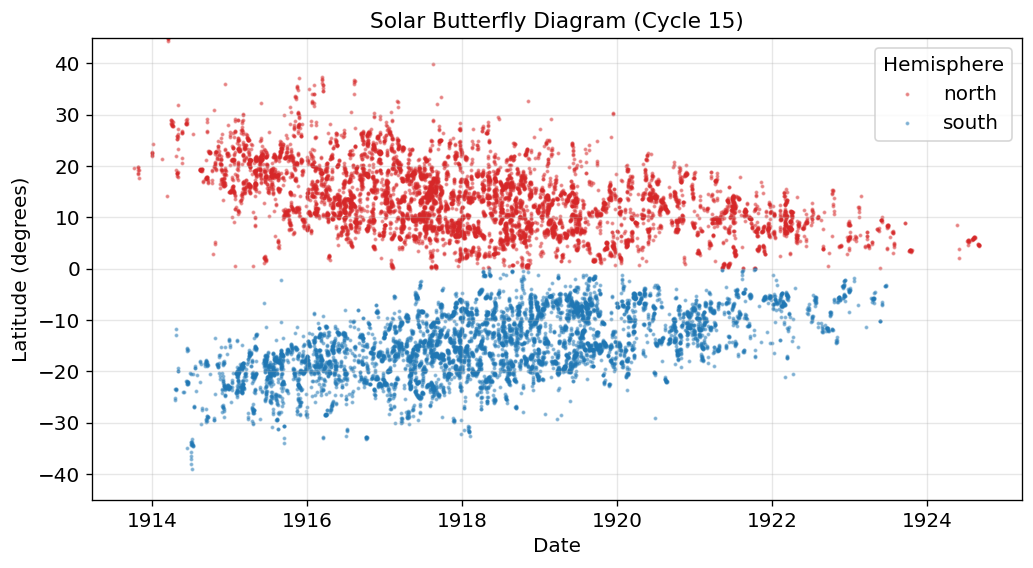

In [ ]:
cycle = 24
df_cycle = df[df['CYCLE'] == cycle].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title(f"Solar Butterfly Diagram (Cycle {cycle})")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

cycle = 20
df_cycle = df[df['CYCLE'] == cycle].copy()
fig1, ax1 = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax1.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax1.set_title(f"Solar Butterfly Diagram (Cycle {cycle})")
ax1.set_xlabel("Date")
ax1.set_ylabel("Latitude (degrees)")
ax1.legend(title="Hemisphere")
ax1.set_ylim(-45, 45)
plt.show()

cycle = 15
df_cycle = df[df['CYCLE'] == cycle].copy()
fig2, ax2 = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax2.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax2.set_title(f"Solar Butterfly Diagram (Cycle {cycle})")
ax2.set_xlabel("Date")
ax2.set_ylabel("Latitude (degrees)")
ax2.legend(title="Hemisphere")
ax2.set_ylim(-45, 45)
plt.show()

Older cycles tended to have slightly higher densities of sunspots compared to the more recent cycle, and the average amplitude of the sunspots was higher among the older cycles as well. The more recent cycle had somewhat narrower wings, reflecting a smaller range of latitudes.

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


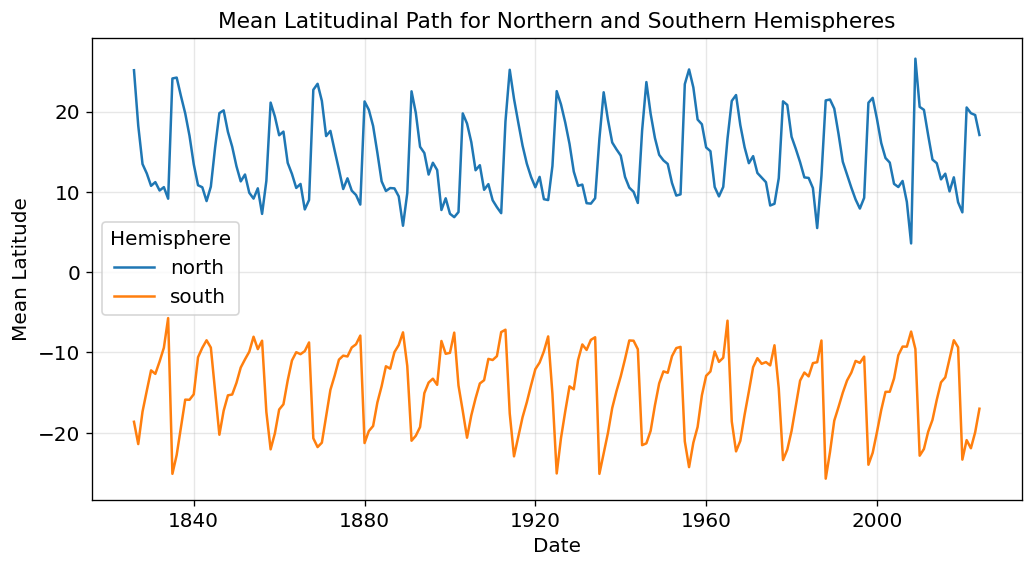

In [ ]:
df_hemisphere = df.groupby(['hemisphere', pd.Grouper(key='date', freq='YE')])['latitude'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_hemisphere.groupby('hemisphere'):
    ax.plot(group['date'], group['latitude'], label=hemi)


ax.set_title("Mean Latitudinal Path for Northern and Southern Hemispheres")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Latitude")
ax.legend(title="Hemisphere")
plt.show()

The mean latitudinal path displays a periodic nature, where a cycle starts farther from the equator, moves toward it as time passes, and then resets for the next cycle. However, the periodicity is not symmetric about the equator, as there are slightly differences in the timing of given events between the northern and southern hemispheres. Therefore, the solar cycle demonstrates some asymmetry between hemispheres.

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


AI Response -

Here are the best ways to prompt an AI assistant to effectively learn machine learning and solar physics:

Ask for Analogies: Both ML and solar physics have abstract concepts. Prompt the AI with: "Explain [concept, e.g., magnetic reconnection or gradient descent] using a simple real-world analogy."

Request Step-by-Step Breakdowns: Avoid getting overwhelmed by complex math or physics. Ask: "Break down the mathematical steps of [concept] like I'm a beginner," or "Walk me through the lifecycle of a sunspot step-by-step."

Combine the Domains: Since you are studying both, ask the AI to bridge them. Prompt: "How would I use a [Specific ML Model, e.g., Random Forest] to predict [Solar Physics Event, e.g., Solar Flares]?"

Ask for 'Toy' Code Examples: When learning ML, ask for minimal, runnable code. Prompt: "Give me a 10-line Python example using pandas and scikit-learn that demonstrates [concept]."

Use the Socratic Method (Don't just ask for the answer): To actively learn, prompt the AI to act as a tutor. Say: "I am trying to plot the solar cycle. Don't give me the exact code, but give me a hint on which pandas function to use to group the dates by year."

Provide Context: Always tell the AI what you already know. "I understand basic Python and pandas, but I am completely new to neural networks. Explain how they work in the context of image recognition for solar images."

Reflection - While I was already familiar with some of these suggestions, there were multiple points that I will begin to implement in future notebooks. In particular, I will leverage the use of analogies to connect unfamiliar ideas to familiar ones, especially with solar physics concepts that could be tied to physics that I already know. Additionally, for the machine learning side, I will employ the "toy" code examples mentioned in the AI response. By seeing examples of implementations, I can comprehend the code while still having the opportunity to apply it correctly in the actual notebook.
